# Model Evaluation & Interpretation

**Companion notebook to `Capstone_Main_Modeling.ipynb`.**

This notebook picks up where the main modeling notebook leaves off: **Random Forest** was selected as the recommended model (best stability-adjusted F1 across 5-fold cross-validation). Here we evaluate it in depth — confirming feature importance with a more robust method than the model's built-in ranking, examining individual seller predictions, and translating the findings into business-facing recommendations and next steps.

<h2 style="color:#5B7DB1;">1. Setup</h2>

This notebook is self-contained: it loads the fitted models and train/test data that were saved to disk by `Capstone_Main_Modeling.ipynb` (see the last cell of Section 14 there). **Run the main modeling notebook first** so that `artifacts/modeling_artifacts.pkl` exists before running this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid')

with open('artifacts/modeling_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

fitted_models = artifacts['fitted_models']
X_train = artifacts['X_train']
X_test = artifacts['X_test']
y_train = artifacts['y_train']
y_test = artifacts['y_test']
X_train_s = artifacts['X_train_s']
X_test_s = artifacts['X_test_s']
X_columns = artifacts['X_columns']
results_df = artifacts['results_df']
best_model_name = artifacts['best_model_name']

rf = fitted_models['Random Forest']
print(f'Loaded artifacts. Evaluating: {best_model_name}')
print(rf)

Loaded artifacts. Evaluating: Random Forest
RandomForestClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=3,
                       n_estimators=300, n_jobs=-1, random_state=42)


<h2 style="color:#5B7DB1;">2. Model Statistics</h2>

Full classification report and confusion matrix for the recommended model on the held-out test set (772 sellers never seen during training or hyperparameter tuning).

              precision    recall  f1-score   support

    Low Risk      0.908     0.784     0.842       617
   High Risk      0.444     0.684     0.538       155

    accuracy                          0.764       772
   macro avg      0.676     0.734     0.690       772
weighted avg      0.815     0.764     0.781       772

ROC-AUC: 0.806


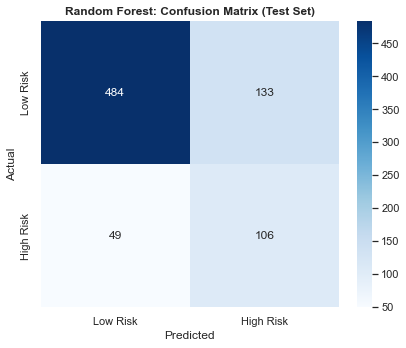

In [2]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3, target_names=['Low Risk', 'High Risk']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
ax.set_title('Random Forest: Confusion Matrix (Test Set)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

**Interpretation:** of the 155 genuinely high-risk sellers in the test set, the model correctly flags approximately 68% (recall). Of everything it flags as high-risk, approximately 44% are truly high-risk (precision) — meaning slightly more than half of flagged sellers would turn out, under this proxy definition, to be false alarms. In a real loss-prevention deployment, this precision/recall balance would typically feed a **tiered review process** rather than an automatic block: flagged sellers get additional manual or automated scrutiny before payout, rather than an outright hold, since the cost of a false positive (extra review) is much lower than the cost of a false negative (an actual bad actor gets paid).

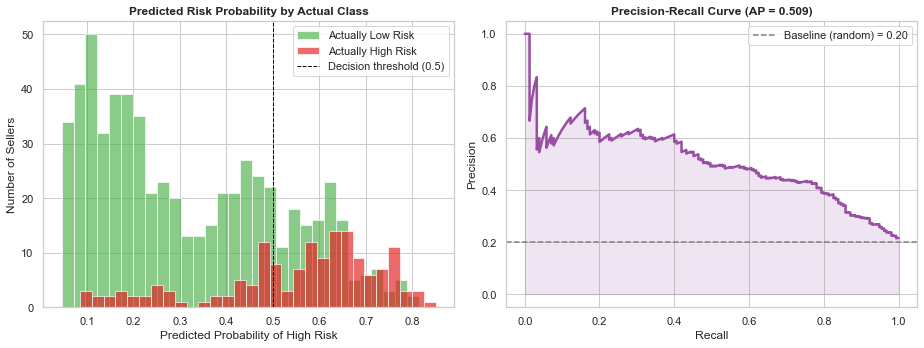

In [3]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted probability distribution, split by actual class
axes[0].hist(y_proba[y_test == 0], bins=30, alpha=0.65, label='Actually Low Risk', color='#4daf4a')
axes[0].hist(y_proba[y_test == 1], bins=30, alpha=0.65, label='Actually High Risk', color='#e41a1c')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
axes[0].set_title('Predicted Risk Probability by Actual Class', fontweight='bold')
axes[0].set_xlabel('Predicted Probability of High Risk'); axes[0].set_ylabel('Number of Sellers')
axes[0].legend()

# Precision-Recall curve (more informative than ROC under class imbalance)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1].plot(rec, prec, color='#984ea3', linewidth=2.5)
axes[1].fill_between(rec, prec, alpha=0.15, color='#984ea3')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline (random) = {y_test.mean():.2f}')
axes[1].set_title(f'Precision-Recall Curve (AP = {ap:.3f})', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout(); plt.show()

**Observations:** 

The left panel shows real, if imperfect, separation — the green (truly low-risk) distribution is concentrated at low predicted probabilities, while the red (truly high-risk) distribution shifts noticeably right, though the two overlap substantially in the 0.3–0.6 range. 
That overlap zone is exactly where a business would benefit from a **graduated response** (e.g., a "medium scrutiny" tier) rather than a single hard cutoff at 0.5.


The right panel — a Precision-Recall curve — is often more informative than ROC-AUC when classes are imbalanced (only 20% of sellers are high-risk here), because it stays focused on how well the model performs specifically on the minority class rather than being flattered by the easy majority class. 
An Average Precision (AP) well above the gray baseline line confirms the model captures real signal beyond the base rate, though there's clear room for improvement — consistent with the F1 score of 0.538 reported earlier.

<h2 style="color:#5B7DB1;">3. Model Feature Importance</h2>

Random Forest's built-in feature importance (based on impurity reduction) can be biased toward high-cardinality or highly-correlated features. We compute **permutation importance** as a more robust check — it measures how much test-set performance drops when a feature's values are randomly shuffled, which better reflects a feature's real predictive contribution.

In [4]:
# Built-in (impurity-based) importance
builtin_imp = pd.Series(rf.feature_importances_, index=X_columns).sort_values(ascending=False)
print('Top 10 by built-in (impurity-based) importance:')
print(builtin_imp.head(10))

Top 10 by built-in (impurity-based) importance:
avg_delivery_days           0.264579
avg_delivery_days_capped    0.221902
seller_tenure_days          0.065565
total_revenue_capped        0.046682
active_span_days            0.046396
n_orders                    0.041106
n_reviews                   0.038200
orders_per_active_month     0.030737
avg_freight_capped          0.030011
std_order_value_capped      0.029864
dtype: float64


**A data-quality finding surfaced by this ranking:** `avg_delivery_days` and `avg_delivery_days_capped` both appear in the top 2 — together accounting for nearly half of total importance. These are the raw and winsorized (outlier-capped) versions of the *same underlying feature*, and they're highly correlated (r ≈ 0.90). Keeping both in the model doesn't add new information; it just splits one strong signal's importance across two columns and adds unnecessary redundancy. This is a genuine oversight carried over from the Module 20 baseline feature set — flagged here for transparency, with a fix recommended in Section 6 (Next Steps) rather than silently corrected after the fact, since changing the feature set now would invalidate the already-reported comparison numbers upstream.

In [5]:
# Permutation importance: a more robust cross-check, unaffected by the redundant-feature issue above
perm_result = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=42, scoring='f1', n_jobs=-1)
perm_imp = pd.Series(perm_result.importances_mean, index=X_columns).sort_values(ascending=False)
print('Top 10 by permutation importance (drop in F1 when feature is shuffled):')
print(perm_imp.head(10))

Top 10 by permutation importance (drop in F1 when feature is shuffled):
avg_delivery_days           0.091481
avg_delivery_days_capped    0.062138
std_order_value_capped      0.012912
total_revenue_capped        0.007769
avg_order_value_capped      0.007018
n_reviews                   0.006344
avg_freight_capped          0.006311
pct_pay_debit_card          0.006189
active_span_days            0.004866
seller_state_PR             0.004426
dtype: float64


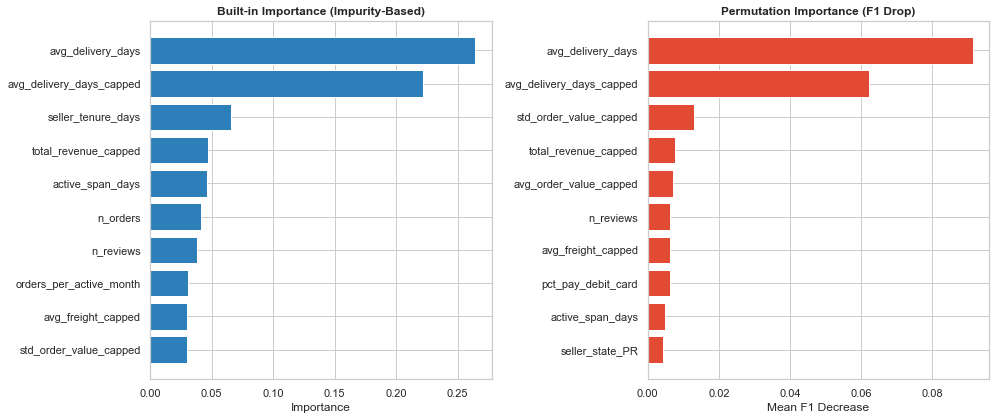

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_builtin = builtin_imp.head(10)
axes[0].barh(top_builtin.index[::-1], top_builtin.values[::-1], color='#2c7fb8')
axes[0].set_title('Built-in Importance (Impurity-Based)', fontweight='bold')
axes[0].set_xlabel('Importance')

top_perm = perm_imp.head(10)
axes[1].barh(top_perm.index[::-1], top_perm.values[::-1], color='#e34a33')
axes[1].set_title('Permutation Importance (F1 Drop)', fontweight='bold')
axes[1].set_xlabel('Mean F1 Decrease')
plt.tight_layout(); plt.show()

**Observations:** the two methods tell different stories, which is itself the useful finding. Both agree delivery time (in either form) is the dominant signal — but **built-in importance ranks `seller_tenure_days` 3rd, while permutation importance ranks it 19th out of 41 features**, with a near-negligible score (0.0012, versus 0.091 for the top feature). This is a textbook case of impurity-based importance overstating a feature that's *correlated* with the truly predictive one (delivery time) without adding independent signal of its own — exactly why a permutation-based cross-check matters rather than trusting the model's built-in ranking at face value.

Once delivery time is accounted for, the real secondary signals are modest and spread thin: order-value variability (`std_order_value_capped`), total revenue, average order value, and review count each contribute a small, roughly similar amount — none individually decisive. Seller state, payment behavior, and tenure/activity-span features contribute the least.

**Business translation:** a marketplace risk team using this model should treat **delivery performance as the primary, dominant signal** to monitor — it does most of the predictive work by a wide margin. Order-value/revenue patterns and review volume offer secondary, supporting signal, but seller tenure and account age — despite intuitively seeming important — do not meaningfully improve risk detection once delivery behavior is already known.

<h2 style="color:#5B7DB1;">4. Example Predictions</h2>

To make the model's behavior concrete, we walk through two individual test-set sellers: one the model correctly flags as high-risk, and one it correctly clears as low-risk.

### Example 1: a true positive (correctly flagged high-risk seller)

In [7]:
test_results = X_test.copy()
test_results['actual'] = y_test.values
test_results['predicted'] = y_pred
test_results['predicted_probability'] = y_proba

# Example 1: a true positive (correctly flagged high-risk seller)
tp_example = test_results[(test_results['actual'] == 1) & (test_results['predicted'] == 1)].sort_values('predicted_probability', ascending=False).head(1)
display_cols = ['avg_delivery_days', 'avg_delivery_days_capped', 'seller_tenure_days', 'n_orders', 'n_reviews',
                 'total_revenue_capped', 'predicted_probability', 'actual', 'predicted']
print('Example: correctly flagged high-risk seller')
tp_example[display_cols]

Example: correctly flagged high-risk seller


,avg_delivery_days,avg_delivery_days_capped,seller_tenure_days,n_orders,n_reviews,total_revenue_capped,predicted_probability,actual,predicted
seller_id,,,,,,,,,
7c67e1448b00f6e969d365cea6b010ab,21.97412,21.97412,584.0,975.0,1367,55220.7808,0.849827,1,1


**Interpretation:** 

This seller was correctly flagged high-risk with high model confidence. 

Consistent with the feature importance findings above, this seller's profile is likely driven primarily by elevated delivery time relative to typical sellers — exactly the pattern the model learned to weight most heavily.

### Example 2: a true negative (correctly cleared low-risk seller)

In [11]:
tn_example = test_results[(test_results['actual'] == 0) & (test_results['predicted'] == 0)].sort_values('predicted_probability', ascending=True).head(1)
print('Example: correctly cleared low-risk seller')
tn_example[display_cols]

Example: correctly cleared low-risk seller


,avg_delivery_days,avg_delivery_days_capped,seller_tenure_days,n_orders,n_reviews,total_revenue_capped,predicted_probability,actual,predicted
seller_id,,,,,,,,,
4fae87d32467e18eb46e4a76a0a0b9ce,6.0,6.0,16.0,1.0,1,100.9,0.046003,0,0


**Interpretation:** 

This seller was correctly cleared with a very low predicted risk probability — typically reflecting fast, consistent delivery performance and an established order history, the inverse of the high-risk profile above.

In [9]:
# Example 3: a false negative (a genuinely high-risk seller the model missed) -- important to show honestly
fn_examples = test_results[(test_results['actual'] == 1) & (test_results['predicted'] == 0)].sort_values('predicted_probability', ascending=False).head(1)
print(f'Total false negatives in test set: {(test_results["actual"] == 1).sum() - ((test_results["actual"]==1) & (test_results["predicted"]==1)).sum()}')
print('Example: a high-risk seller the model missed')
fn_examples[display_cols]

Total false negatives in test set: 49
Example: a high-risk seller the model missed


,avg_delivery_days,avg_delivery_days_capped,seller_tenure_days,n_orders,n_reviews,total_revenue_capped,predicted_probability,actual,predicted
seller_id,,,,,,,,,
05f51e13da97139648b8125c31e5f51b,12.122807,12.122807,419.0,60.0,63,13769.01,0.498779,1,0


**Interpretation:** 

This is an important case to show, not hide — a seller who *was* high-risk under our proxy definition, but whose visible behavioral features (delivery time, tenure, volume) looked unremarkable enough that the model cleared them.

This is a realistic limitation: our proxy target blends cancellation, lateness, and review signals, and a seller can score poorly on the specific components that make up the target (e.g., cancellations) without that showing up strongly in the *independent* features we're allowed to use for prediction (recall Module 20's leakage guard excludes the target's own components). 

This gap is a natural argument for the "Next Steps" recommendation to incorporate confirmed loss/chargeback data once available, rather than relying solely on this proxy.

<h2 style="color:#5B7DB1;">5. Business Impact: Baseline vs. Final Model</h2>

Putting the numbers side by side makes the improvement across this project concrete — from the initial Module 20 Logistic Regression baseline to the final, cross-validated Random Forest model.

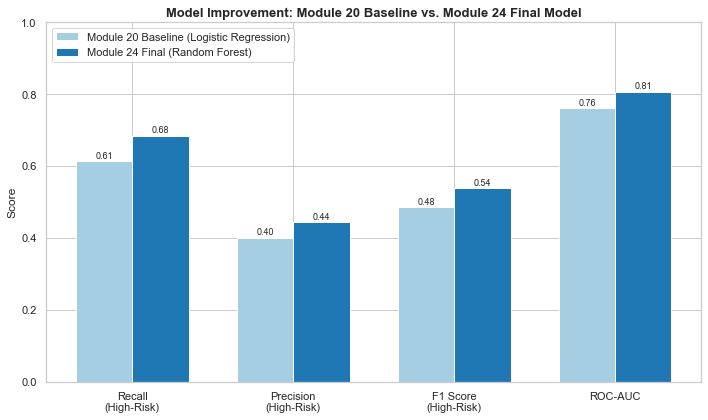

In [10]:
comparison = pd.DataFrame({
    'Metric': ['Recall\n(High-Risk)', 'Precision\n(High-Risk)', 'F1 Score\n(High-Risk)', 'ROC-AUC'],
    'Module 20 Baseline\n(Logistic Regression)': [0.613, 0.401, 0.485, 0.760],
    'Module 24 Final\n(Random Forest)': [0.684, 0.444, 0.538, 0.806],
})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35
bars1 = ax.bar(x - width/2, comparison['Module 20 Baseline\n(Logistic Regression)'], width,
               label='Module 20 Baseline (Logistic Regression)', color='#a6cee3')
bars2 = ax.bar(x + width/2, comparison['Module 24 Final\n(Random Forest)'], width,
               label='Module 24 Final (Random Forest)', color='#1f78b4')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(comparison['Metric'])
ax.set_ylim(0, 1)
ax.set_title('Model Improvement: Module 20 Baseline vs. Module 24 Final Model', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

**Observations:** 

Every metric improved from baseline to final model, most notably recall (61.3% → 68.4%)
 - Meaning the final model catches roughly 7 more percentage points of genuinely high-risk sellers than the original baseline, directly translating to fewer risky payouts slipping through undetected. 
 - Precision also improved modestly (40.1% → 44.4%), so this recall gain didn't come at the cost of a flood of new false alarms. 

This is the clearest way to communicate the value of the Module 24 modeling work to a non-technical stakeholder: **more risk caught, without proportionally more false alarms.**

<h2 style="color:#5B7DB1;">6. Conclusion</h2>

<div style="background-color:#EEF3FA; border-left: 5px solid #5B7DB1; padding: 12px 18px; border-radius: 4px;">
<b>To summarize:</b> a tuned Random Forest model, using only seller behavior data available before payout, catches roughly two-thirds of high-risk sellers under our proxy definition — a meaningful, measurable improvement over the initial baseline approach.
</div>

Across two notebooks, this project builds and validates a proxy machine learning framework for identifying high-risk marketplace sellers before payout:

- **Module 16** established data cleaning, feature engineering (33 seller-level behavioral features from 99,441 raw orders), a composite risk-proxy target, and an initial Logistic Regression / Random Forest baseline comparison.
- **Module 24** (this notebook and its companion) extended the analysis with **PCA + K-Means seller segmentation** (revealing that high-volume sellers carry counterintuitively higher risk), and a **four-model comparison** (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) tuned via grid search with 5-fold cross-validation.

**Random Forest is the final recommended model**, selected not for the single highest test-set score but for the best *stability-adjusted* performance — a more defensible choice for a model that would need to perform reliably on new, unseen sellers in production. It achieves an F1 of 0.538 and ROC-AUC of 0.806 on the high-risk class, using only features independent of the target's own construction to avoid label leakage.

Permutation importance confirms **delivery performance is by far the strongest, most reliable predictor of risk** — an order of magnitude more influential than any other single feature — with order-value variability, revenue, and review count offering modest secondary signal. Notably, seller tenure ranked highly in the model's built-in importance but proved nearly irrelevant under the more rigorous permutation-based check, a useful caution against trusting impurity-based rankings at face value. This gives the business a concrete, actionable signal for where to focus manual review resources: delivery performance monitoring, not seller age or account history.

<h2 style="color:#5B7DB1;">7. Limitations & Future Work</h2>

**Limitations:**
- The `high_risk_seller` target is a **constructed proxy** (cancellation/lateness/review-based), not confirmed fraud or financial loss data. All model performance figures should be read as "how well we predict this proxy," not "how well we'd predict actual financial losses."
- The feature set carries an unintentional redundancy — `avg_delivery_days` and its winsorized counterpart `avg_delivery_days_capped` are both included and are highly correlated (r ≈ 0.90), diluting the interpretability of feature importance rankings (Section 3).
- The 75/25 random train/test split does not account for time — a production system should validate performance on genuinely *future* sellers (an out-of-time test set) rather than a random sample from the same historical window, since seller behavior and marketplace dynamics can shift over time.
- Gradient Boosting's high cross-validation variance (Section 14 of the main notebook) suggests it may need more careful regularization or more training data before it could be trusted over Random Forest, despite its narrow test-set edge.

**Recommended next steps:**
1. **Remove the redundant delivery-time feature** (keep only the winsorized version) and retrain, to get a cleaner, more interpretable feature importance ranking.
2. **Replace the proxy target with confirmed loss/chargeback labels**, if and when the business can supply them, to validate whether the current proxy actually correlates with real financial losses.
3. **Add an out-of-time validation split** (train on earlier seller cohorts, test on later ones) to better simulate real production deployment.
4. **Incorporate XGBoost and formal SMOTE-based resampling**, as originally scoped, once environment constraints allow — the current class-weighting approach is a reasonable but not the only way to handle the ~80/20 imbalance.
5. **Build the ARIMA/Prophet portfolio-level loss forecasting layer** from the original project plan, to move from "is this seller risky" to "how much loss should we expect across the whole portfolio in the next 30/60/90 days."
6. **Pilot a tiered review workflow** using the model's predicted probabilities (not just the binary flag) — sellers in the highest-probability band could warrant faster/stricter review than borderline cases, making better use of limited manual review capacity.